# Rice Type Classification Project



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
df = pd.read_csv('riceClassification.csv')
df.head()


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [3]:
# Dataset Information
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())


(18185, 12)
Index(['id', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
me

In [4]:
# Data Cleaning
if 'id' in df.columns:
    df=df.drop('id',axis=1)

if df['Class'].dtype=='object':
    df['Class']=df['Class'].map({'Cammeo':0,'Osmancik':1})

X=df.drop('Class',axis=1)
y=df['Class']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [5]:
results={}
predictions={}

def evaluate(name,model,Xtr,Xte):
    model.fit(Xtr,y_train)
    pred=model.predict(Xte)
    predictions[name]=pred
    results[name]={
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred),
        'Recall':recall_score(y_test,pred),
        'F1 Score':f1_score(y_test,pred)
    }
    print(name)
    print(classification_report(y_test,pred))
    return model

lr=evaluate("Logistic Regression",LogisticRegression(max_iter=1000),X_train_scaled,X_test_scaled)
dt=evaluate("Decision Tree",DecisionTreeClassifier(random_state=42),X_train,X_test)
rf=evaluate("Random Forest",RandomForestClassifier(random_state=42),X_train,X_test)
svm=evaluate("Support Vector Machine",SVC(),X_train_scaled,X_test_scaled)
knn=evaluate("K-Nearest Neighbors",KNeighborsClassifier(),X_train_scaled,X_test_scaled)
gb=evaluate("Gradient Boosting",GradientBoostingClassifier(random_state=42),X_train,X_test)


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1640
           1       0.99      0.99      0.99      1997

    accuracy                           0.99      3637
   macro avg       0.99      0.99      0.99      3637
weighted avg       0.99      0.99      0.99      3637

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1640
           1       0.99      0.98      0.99      1997

    accuracy                           0.98      3637
   macro avg       0.98      0.98      0.98      3637
weighted avg       0.98      0.98      0.98      3637

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1640
           1       0.99      0.99      0.99      1997

    accuracy                           0.99      3637
   macro avg       0.99      0.99      0.99      3637
weighted avg       0.99   

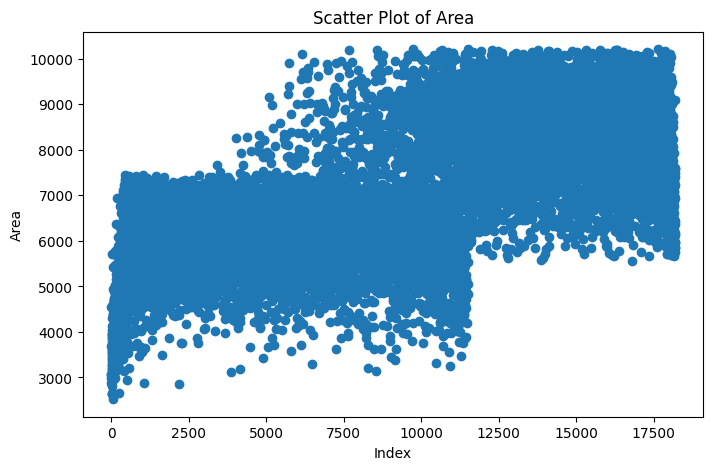

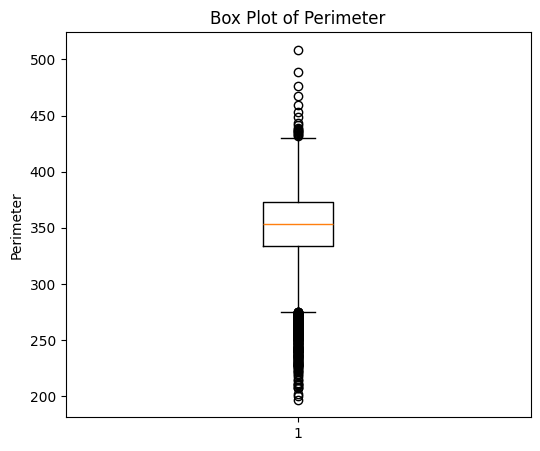

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv(r"riceClassification.csv")

# Scatter Plot
x = range(len(df['Area']))
y = df['Area']

plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.xlabel("Index")
plt.ylabel("Area")
plt.title("Scatter Plot of Area")
plt.show()

# Box Plot
y = df['Perimeter']

plt.figure(figsize=(6,5))
plt.boxplot(y)
plt.ylabel("Perimeter")
plt.title("Box Plot of Perimeter")
plt.show()

In [10]:
# Numerical Columns
columns = [
    'Area',
    'MajorAxisLength',
    'MinorAxisLength',
    'Eccentricity',
    'ConvexArea',
    'EquivDiameter',
    'Extent',
    'Perimeter',
    'Roundness',
    'AspectRation'
]

# Find IQR and Z-Score Outliers
for col in columns:

    # IQR
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("="*60)
    print(f"Column : {col}")

    print("\nNOW USING IQR")
    print("-"*30)
    print(f"Q1 : {q1:.2f}")
    print(f"Q3 : {q3:.2f}")
    print(f"IQR : {iqr:.2f}")
    print(f"Lower Limit : {lower:.2f}")
    print(f"Upper Limit : {upper:.2f}")
    print(f"Number of Outliers : {len(iqr_outliers)}")

    # Z-Score
    mean = df[col].mean()
    std = df[col].std()

    z_score = (df[col] - mean) / std

    z_outliers = df[z_score.abs() > 3]

    print("\nNOW USING Z-SCORE")
    print("-"*30)
    print(f"Mean : {mean:.2f}")
    print(f"Standard Deviation : {std:.2f}")
    print(f"Number of Outliers : {len(z_outliers)}")

print("="*60)

Column : Area

NOW USING IQR
------------------------------
Q1 : 5962.00
Q3 : 8423.00
IQR : 2461.00
Lower Limit : 2270.50
Upper Limit : 12114.50
Number of Outliers : 0

NOW USING Z-SCORE
------------------------------
Mean : 7036.49
Standard Deviation : 1467.20
Number of Outliers : 2
Column : MajorAxisLength

NOW USING IQR
------------------------------
Q1 : 145.68
Q3 : 160.06
IQR : 14.38
Lower Limit : 124.11
Upper Limit : 181.63
Number of Outliers : 538

NOW USING Z-SCORE
------------------------------
Mean : 151.68
Standard Deviation : 12.38
Number of Outliers : 319
Column : MinorAxisLength

NOW USING IQR
------------------------------
Q1 : 51.39
Q3 : 70.16
IQR : 18.76
Lower Limit : 23.25
Upper Limit : 98.30
Number of Outliers : 0

NOW USING Z-SCORE
------------------------------
Mean : 59.81
Standard Deviation : 10.06
Number of Outliers : 0
Column : Eccentricity

NOW USING IQR
------------------------------
Q1 : 0.89
Q3 : 0.94
IQR : 0.05
Lower Limit : 0.82
Upper Limit : 1.02
Number 

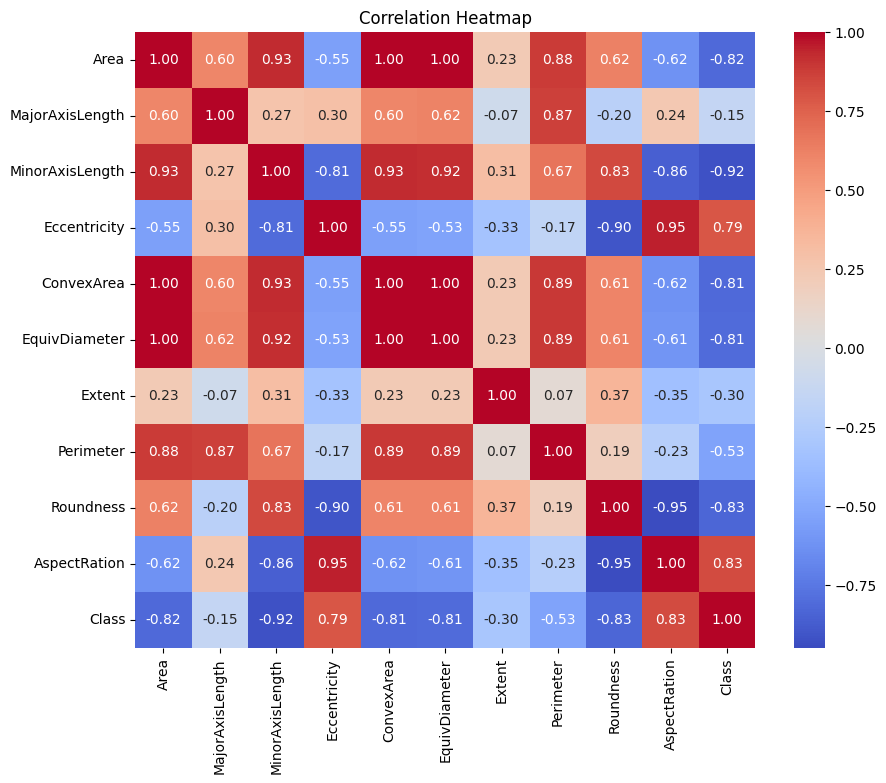

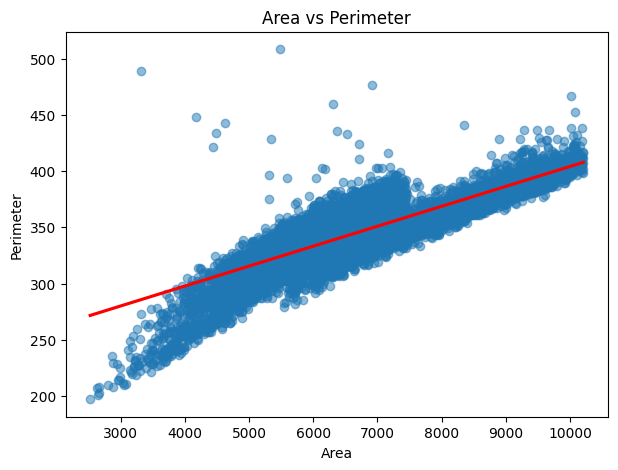

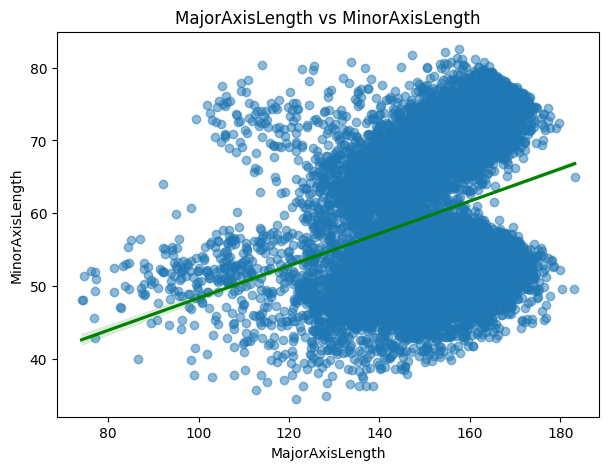

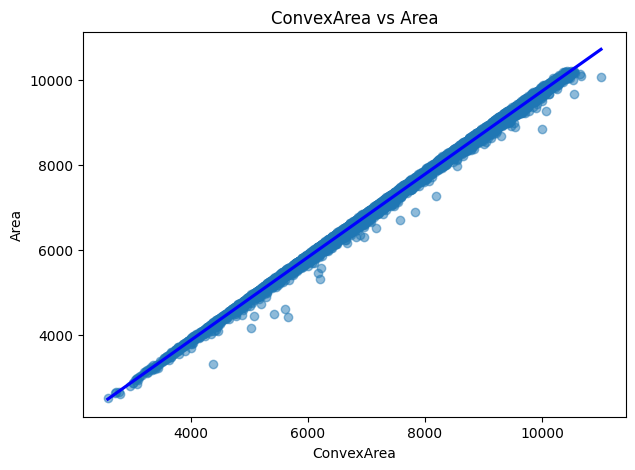

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove ID column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Convert Class into numeric (if it is text)
if df['Class'].dtype == 'object':
    df['Class'] = df['Class'].map({
        'Cammeo': 0,
        'Osmancik': 1
    })

# -----------------------------
# Correlation Heatmap
# -----------------------------
corr = df.corr(numeric_only=True)

n = len(corr.columns)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# --------------------------------
# Regression Plot 1
# --------------------------------
plt.figure(figsize=(7,5))

sns.regplot(
    x='Area',
    y='Perimeter',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Area vs Perimeter")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.show()

# --------------------------------
# Regression Plot 2
# --------------------------------
plt.figure(figsize=(7,5))

sns.regplot(
    x='MajorAxisLength',
    y='MinorAxisLength',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'green'}
)

plt.title("MajorAxisLength vs MinorAxisLength")
plt.xlabel("MajorAxisLength")
plt.ylabel("MinorAxisLength")
plt.show()

# --------------------------------
# Regression Plot 3
# --------------------------------
plt.figure(figsize=(7,5))

sns.regplot(
    x='ConvexArea',
    y='Area',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'blue'}
)

plt.title("ConvexArea vs Area")
plt.xlabel("ConvexArea")
plt.ylabel("Area")
plt.show()

In [13]:
# Check Missing Values
print("Missing Values Before Filling:\n")
print(df.isnull().sum())

# Fill missing values (if any) with the column mean
numerical_columns = [
    'Area',
    'MajorAxisLength',
    'MinorAxisLength',
    'Eccentricity',
    'ConvexArea',
    'EquivDiameter',
    'Extent',
    'Perimeter',
    'Roundness',
    'AspectRation'
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

print("\nMissing Values After Filling:\n")
print(df.isnull().sum())

# Select Features (X) and Target (Y)
X = df[
    [
        'Area',
        'MajorAxisLength',
        'MinorAxisLength',
        'Eccentricity',
        'ConvexArea',
        'EquivDiameter',
        'Extent',
        'Perimeter',
        'Roundness',
        'AspectRation'
    ]
]

Y = df['Class']

print("\nFeatures Shape :", X.shape)
print("Target Shape :", Y.shape)

print("\nFirst 5 Rows of Features:")
print(X.head())

print("\nFirst 5 Target Values:")
print(Y.head())

Missing Values Before Filling:

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

Missing Values After Filling:

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

Features Shape : (18185, 10)
Target Shape : (18185,)

First 5 Rows of Features:
   Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  4537        92.229316        64.012769      0.719916        4677   
1  2872        74.691881        51.400454      0.725553        3015   
2  3048        76.293164        52.043491      0.731211        3132   
3  3073        77.033628        51.928487      0.738639        3157   
4  3693     

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Remove id column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Convert Class to numeric if needed
if df['Class'].dtype == 'object':
    df['Class'] = df['Class'].map({
        'Cammeo': 0,
        'Osmancik': 1
    })

# Features and Target
X = df[
    [
        'Area',
        'MajorAxisLength',
        'MinorAxisLength',
        'Eccentricity',
        'ConvexArea',
        'EquivDiameter',
        'Extent',
        'Perimeter',
        'Roundness',
        'AspectRation'
    ]
]

Y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
Classifier_LR = LogisticRegression(max_iter=1000)

Classifier_LR.fit(X_train, y_train)

# Prediction
y_predlr = Classifier_LR.predict(X_test)

# Accuracy
S_LR = accuracy_score(y_test, y_predlr)

print("Logistic Regression Accuracy :", S_LR)

Logistic Regression Accuracy : 0.9920263953808084


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the Decision Tree Model
Classifier_DT = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42
)

# Train the model
Classifier_DT.fit(X_train, y_train)

# Make Predictions
y_preddt = Classifier_DT.predict(X_test)

# Calculate Accuracy
S_DT = accuracy_score(y_test, y_preddt)

# Print Accuracy
print("Decision Tree Accuracy:", S_DT)

Decision Tree Accuracy: 0.9870772614792411


In [17]:
# Handling Outliers using Isolation Forest

from sklearn.ensemble import IsolationForest

# Create Isolation Forest Model
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Detect Outliers
outlier_labels = iso_forest.fit_predict(X_train)   # -1 = Outlier, 1 = Normal

# Create Mask
outlier_mask = outlier_labels == -1

# Display Only Outlier Rows
outlier_rows = X_train[outlier_mask]

print("Number of Outliers:", len(outlier_rows))
print(outlier_rows)

Number of Outliers: 728
[[-1.79606426 -3.87763383 -0.45271232 ... -2.99621754  1.33973978
  -1.66068361]
 [ 2.07209139  0.87752085  1.95648142 ...  2.26132732  0.22946117
  -1.2731822 ]
 [-1.944892   -0.98014548 -2.02286443 ... -1.67292918 -1.95945703
   2.15212341]
 ...
 [-1.82132402 -0.56046409 -2.11348134 ... -1.48490634 -1.90824884
   2.65367333]
 [ 2.16425535  1.1504518   1.88649809 ...  1.58734404  1.48354344
  -1.132647  ]
 [-1.98926724 -3.89190405 -0.74797417 ... -3.25515204  1.2504697
  -1.42360663]]


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the Random Forest Model
Classifier_RF = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# Train the Model
Classifier_RF.fit(X_train, y_train)

# Make Predictions
y_predrf = Classifier_RF.predict(X_test)

# Calculate Accuracy
S_RF = accuracy_score(y_test, y_predrf)

# Print Accuracy
print("Random Forest Accuracy:", S_RF)

Random Forest Accuracy: 0.991751443497388


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create the SVM Model
Classifier_SVC = SVC(
    kernel='rbf',
    C=100,
    gamma='scale'
)

# Train the Model
Classifier_SVC.fit(X_train, y_train)

# Make Predictions
y_predsvc = Classifier_SVC.predict(X_test)

# Calculate Accuracy
S_SVC = accuracy_score(y_test, y_predsvc)

# Print Accuracy
print("SVM Accuracy:", S_SVC)

SVM Accuracy: 0.991751443497388


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Create the model
Classifier_KNN = KNeighborsClassifier(n_neighbors=5,weights='uniform',metric='minkowski',p=2)

# Train the model
Classifier_KNN.fit(X_train, y_train)

# Make predictions
y_predkn = Classifier_KNN.predict(X_test)

# Calculate R² score
S_KNN = accuracy_score(y_test, y_predkn)

# Print the score
print("accuracy_score:", S_KNN)

accuracy_score: 0.9912015397305471


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Create the Gradient Boosting Model
Classifier_GB = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the Model
Classifier_GB.fit(X_train, y_train)

# Make Predictions
y_predgb = Classifier_GB.predict(X_test)

# Calculate Accuracy
S_GB = accuracy_score(y_test, y_predgb)

# Print Accuracy
print("Gradient Boosting Accuracy:", S_GB)

Gradient Boosting Accuracy: 0.9914764916139676


In [22]:
import pandas as pd

# Get first 3 actual values
actual = y_test.iloc[:3].values

# Convert Actual values to Rice Class Names
actual_class = ["Cammeo" if x == 0 else "Osmancik" for x in actual]

# Function to convert predictions
def convert_prediction(predictions):
    return ["Cammeo" if x == 0 else "Osmancik" for x in predictions[:3]]

# Convert predictions
lr_pred = convert_prediction(y_predlr)
dt_pred = convert_prediction(y_preddt)
rf_pred = convert_prediction(y_predrf)
svm_pred = convert_prediction(y_predsvc)
knn_pred = convert_prediction(y_predkn)
gb_pred = convert_prediction(y_predgb)

# Final Comparison Table
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'KNN',
        'Gradient Boosting'
    ],
    'Accuracy': [
        S_LR,
        S_DT,
        S_RF,
        S_SVC,
        S_KNN,
        S_GB
    ],
    'Actual 1': [actual_class[0]] * 6,
    'Prediction 1': [
        lr_pred[0],
        dt_pred[0],
        rf_pred[0],
        svm_pred[0],
        knn_pred[0],
        gb_pred[0]
    ],
    'Actual 2': [actual_class[1]] * 6,
    'Prediction 2': [
        lr_pred[1],
        dt_pred[1],
        rf_pred[1],
        svm_pred[1],
        knn_pred[1],
        gb_pred[1]
    ],
    'Actual 3': [actual_class[2]] * 6,
    'Prediction 3': [
        lr_pred[2],
        dt_pred[2],
        rf_pred[2],
        svm_pred[2],
        knn_pred[2],
        gb_pred[2]
    ]
})

print(results)

             Algorithm  Accuracy  Actual 1 Prediction 1 Actual 2 Prediction 2  \
0  Logistic Regression  0.992026  Osmancik     Osmancik   Cammeo       Cammeo   
1        Decision Tree  0.987077  Osmancik     Osmancik   Cammeo       Cammeo   
2        Random Forest  0.991751  Osmancik     Osmancik   Cammeo       Cammeo   
3                  SVM  0.991751  Osmancik     Osmancik   Cammeo       Cammeo   
4                  KNN  0.991202  Osmancik     Osmancik   Cammeo       Cammeo   
5    Gradient Boosting  0.991476  Osmancik     Osmancik   Cammeo       Cammeo   

  Actual 3 Prediction 3  
0   Cammeo       Cammeo  
1   Cammeo       Cammeo  
2   Cammeo       Cammeo  
3   Cammeo       Cammeo  
4   Cammeo       Cammeo  
5   Cammeo       Cammeo  


In [24]:
import pandas as pd

a = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'Support Vector Machine Classifier',
        'K-Nearest Neighbor Classifier',
        'Gradient Boosting Classifier'
    ],

    'Accuracy': [
        S_LR,
        S_DT,
        S_RF,
        S_SVC,
        S_KNN,
        S_GB
    ],

    'Actual1': [
        actual_class[0],
        actual_class[0],
        actual_class[0],
        actual_class[0],
        actual_class[0],
        actual_class[0]
    ],

    'Prediction1': [
        lr_pred[0],
        dt_pred[0],
        rf_pred[0],
        svm_pred[0],
        knn_pred[0],
        gb_pred[0]
    ],

    'Actual2': [
        actual_class[1],
        actual_class[1],
        actual_class[1],
        actual_class[1],
        actual_class[1],
        actual_class[1]
    ],

    'Prediction2': [
        lr_pred[1],
        dt_pred[1],
        rf_pred[1],
        svm_pred[1],
        knn_pred[1],
        gb_pred[1]
    ],

    'Actual3': [
        actual_class[2],
        actual_class[2],
        actual_class[2],
        actual_class[2],
        actual_class[2],
        actual_class[2]
    ],

    'Prediction3': [
        lr_pred[2],
        dt_pred[2],
        rf_pred[2],
        svm_pred[2],
        knn_pred[2],
        gb_pred[2]
    ]
})

a

,Algorithm,Accuracy,Actual1,Prediction1,Actual2,Prediction2,Actual3,Prediction3
0,Logistic Regression,0.992026,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo
1,Decision Tree Classifier,0.987077,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo
2,Random Forest Classifier,0.991751,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo
3,Support Vector Machine Classifier,0.991751,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo
4,K-Nearest Neighbor Classifier,0.991202,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo
5,Gradient Boosting Classifier,0.991476,Osmancik,Osmancik,Cammeo,Cammeo,Cammeo,Cammeo


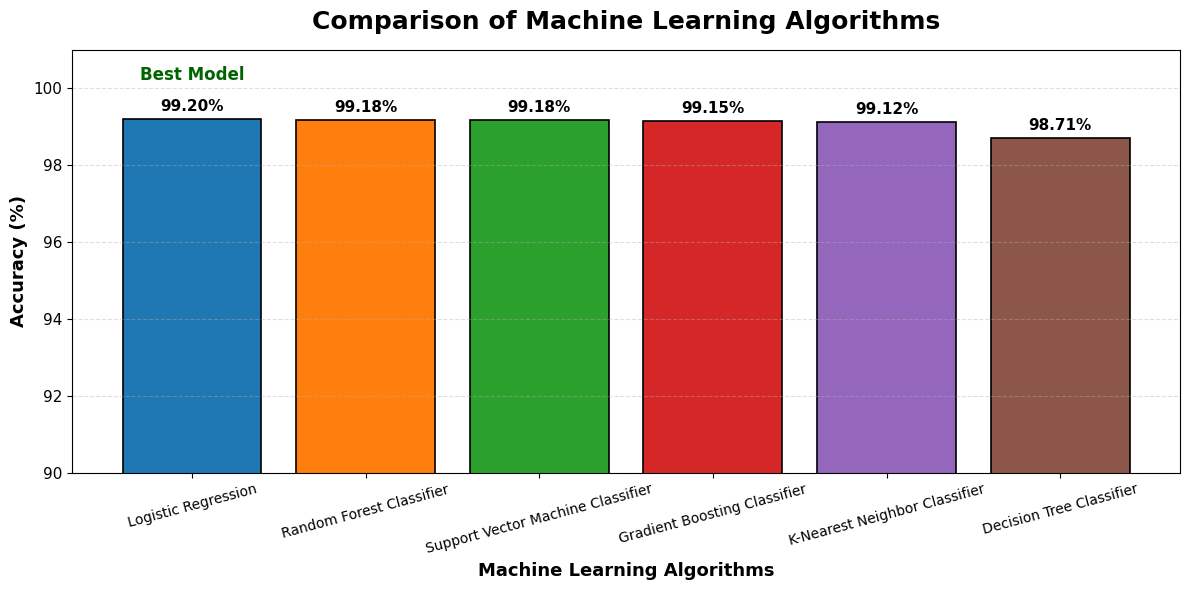

In [26]:
import matplotlib.pyplot as plt

# Create a copy
accuracy_df = a.copy()

# Convert Accuracy to Percentage
accuracy_df['Accuracy'] = accuracy_df['Accuracy'] * 100

# Sort by Accuracy (Highest First)
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12,6))

bars = plt.bar(
    accuracy_df['Algorithm'],
    accuracy_df['Accuracy'],
    color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'],
    edgecolor='black',
    linewidth=1.2
)

plt.title(
    "Comparison of Machine Learning Algorithms",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Machine Learning Algorithms",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13,
    fontweight='bold'
)

plt.ylim(90,101)        # Adjust according to your results
plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Show Accuracy on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Highlight Best Model
best = accuracy_df.iloc[0]

plt.text(
    0,
    best['Accuracy'] + 1,
    "Best Model",
    ha='center',
    fontsize=12,
    color='darkgreen',
    fontweight='bold'
)

plt.tight_layout()

plt.show()

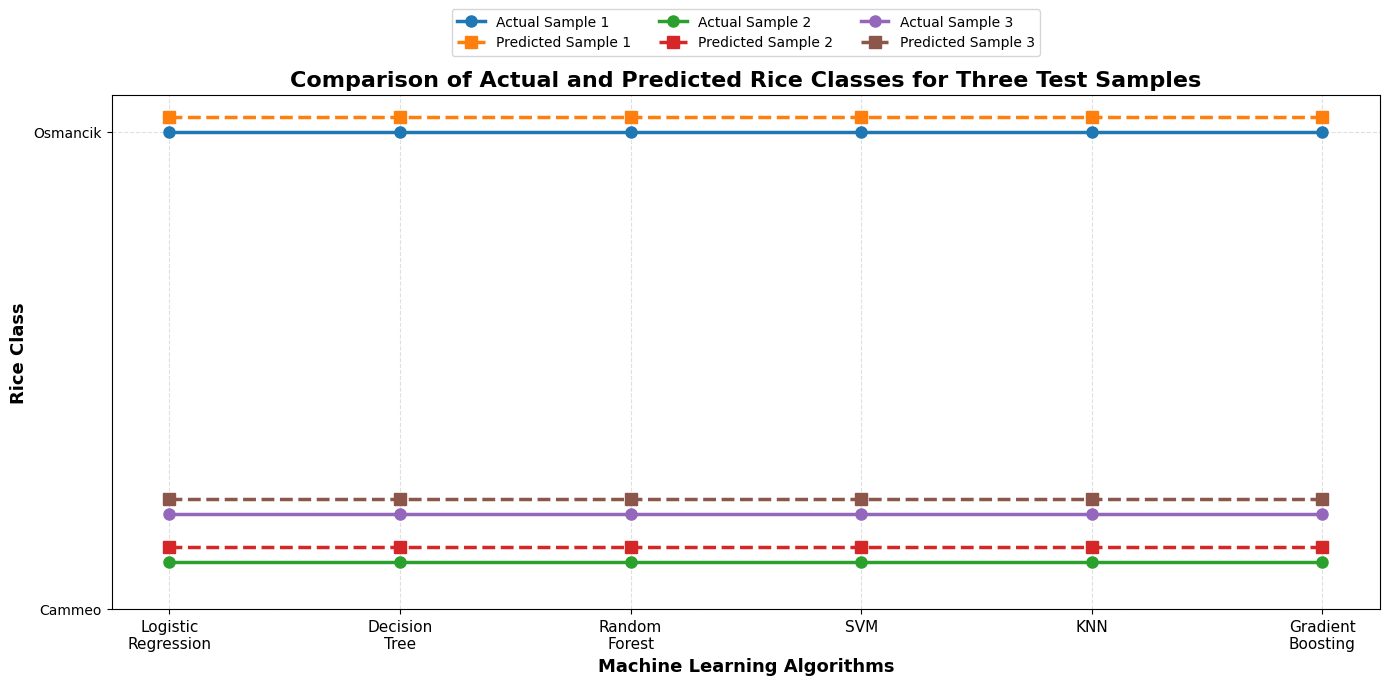

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Convert class labels to numbers
mapping = {'Cammeo': 0, 'Osmancik': 1}

plot_df = a.copy()

for col in ['Actual1','Prediction1',
            'Actual2','Prediction2',
            'Actual3','Prediction3']:
    plot_df[col] = plot_df[col].map(mapping)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14,7))

# -------- Sample 1 --------
ax.plot(x, plot_df['Actual1'],
        marker='o', linewidth=2.5, markersize=8,
        label='Actual Sample 1')

ax.plot(x, plot_df['Prediction1']+0.03,
        marker='s', linewidth=2.5, markersize=8,
        linestyle='--',
        label='Predicted Sample 1')

# -------- Sample 2 --------
ax.plot(x, plot_df['Actual2']+0.10,
        marker='o', linewidth=2.5, markersize=8,
        label='Actual Sample 2')

ax.plot(x, plot_df['Prediction2']+0.13,
        marker='s', linewidth=2.5, markersize=8,
        linestyle='--',
        label='Predicted Sample 2')

# -------- Sample 3 --------
ax.plot(x, plot_df['Actual3']+0.20,
        marker='o', linewidth=2.5, markersize=8,
        label='Actual Sample 3')

ax.plot(x, plot_df['Prediction3']+0.23,
        marker='s', linewidth=2.5, markersize=8,
        linestyle='--',
        label='Predicted Sample 3')

ax.set_xticks(x)
ax.set_xticklabels([
    'Logistic\nRegression',
    'Decision\nTree',
    'Random\nForest',
    'SVM',
    'KNN',
    'Gradient\nBoosting'
], fontsize=11)

ax.set_yticks([0,1])
ax.set_yticklabels(['Cammeo','Osmancik'])

ax.set_xlabel("Machine Learning Algorithms",
              fontsize=13,
              fontweight='bold')

ax.set_ylabel("Rice Class",
              fontsize=13,
              fontweight='bold')

ax.set_title("Comparison of Actual and Predicted Rice Classes for Three Test Samples",
             fontsize=16,
             fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(loc='upper center',
          bbox_to_anchor=(0.5,1.18),
          ncol=3)

plt.tight_layout()
plt.show()

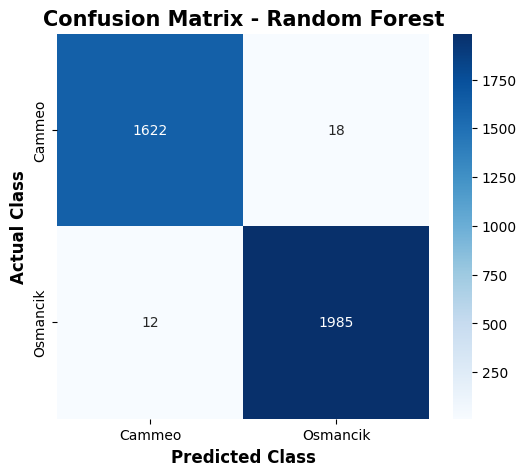

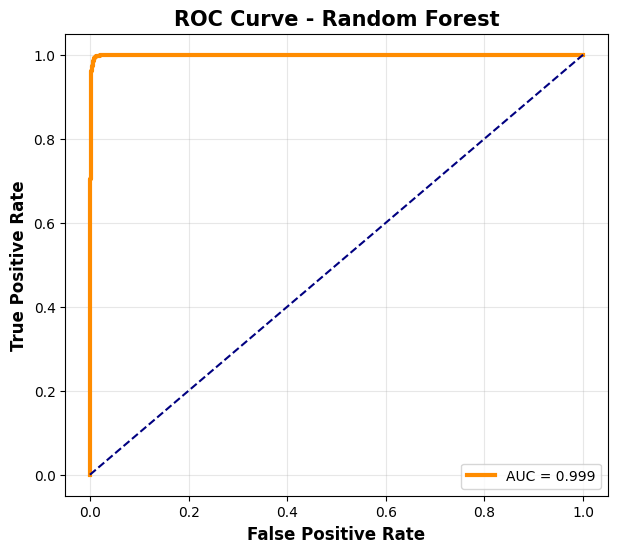

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = Classifier_RF.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,
         color='darkorange',
         linewidth=3,
         label='AUC = %0.3f'%roc_auc)

plt.plot([0,1],[0,1],
         linestyle='--',
         color='navy')

plt.xlabel("False Positive Rate",fontsize=12,fontweight='bold')
plt.ylabel("True Positive Rate",fontsize=12,fontweight='bold')
plt.title("ROC Curve - Random Forest",fontsize=15,fontweight='bold')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.show()

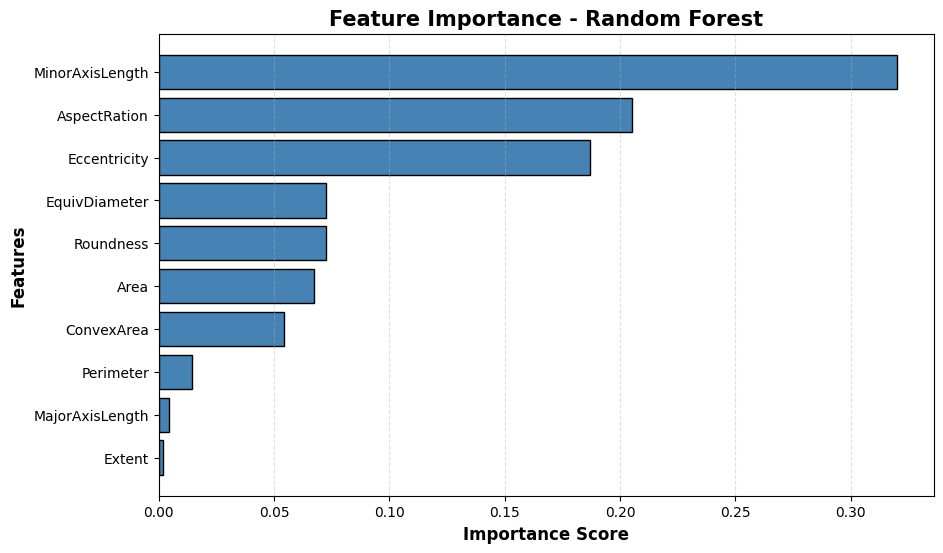

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':Classifier_RF.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance'],
    color='steelblue',
    edgecolor='black'
)

plt.title("Feature Importance - Random Forest",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Importance Score",
           fontsize=12,
           fontweight='bold')

plt.ylabel("Features",
           fontsize=12,
           fontweight='bold')

plt.grid(axis='x',linestyle='--',alpha=0.4)

plt.show()